## Mini-Project 2 - Kolja Grosse - 7335625

**Performance of MLP vs CNN on Fashion MNIST Dataset**

In this Juypter Notebook I will complete the 5 tasks of the 2nd mini project. This is my first time working with neural networks, so I tried to make the notebook as simple as possible to follow along, simply to make it easier for myself.<br>

**Grid Search Switch:** I have created a switch in this notebook. If you set "run_real_grid_search" to true, the notebook will run the actual grid search. If it is set to False, the notebook will run with the hard coded result of the grid search I already performed. I have decided to do a computationally expensive grid search, so I advise to leave it at False.

In [1]:
# set to 'True' if you want to perform the grid search
run_real_grid_search = False

Lets start with gathering the data:

In [2]:
#Getting the Dataset - TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

***Task 1 — Data Exploration and Preparation***

**1.1 - Dataset inspection**

For Task 1 some of the *console print-outs* should be viewed as *markdown cells*. This is so I can utilize pythons f-string functionality.

The fashion_mnist dataset consists of 70000 labeled 28x28p grayscale images of fashion items.
The dataset is split up into four numpy arrays (X_train, y_train, X_test and y_test).

X_train and y_train make up the training set with 60000 images, whereas X_test and y_test make up the test set with 10000 images.

The input (X_train/X_test) is saved in a 3-dimensional <class 'numpy.ndarray'>.
The first dimension can be understood as the id of the image and the 2nd and 3rd dimension store the 28x28p image.
A pixel has a value between 0 and 255.

The label (y_train/y_test) is a 1-dimensional <class 'numpy.ndarray'>. A label is a number between  0 and 9.
The numbers have the following meaning:
	0 = T-shirt/top
	1 = Trouser
	2 = Pullover
	3 = Dress
	4 = Coat
	5 = Sandal
	6 = Shirt
	7 = Sneaker
	8 = Bag
	9 = Ankle boot
Now lets see one example for each of the different labels in addition to the distribution:


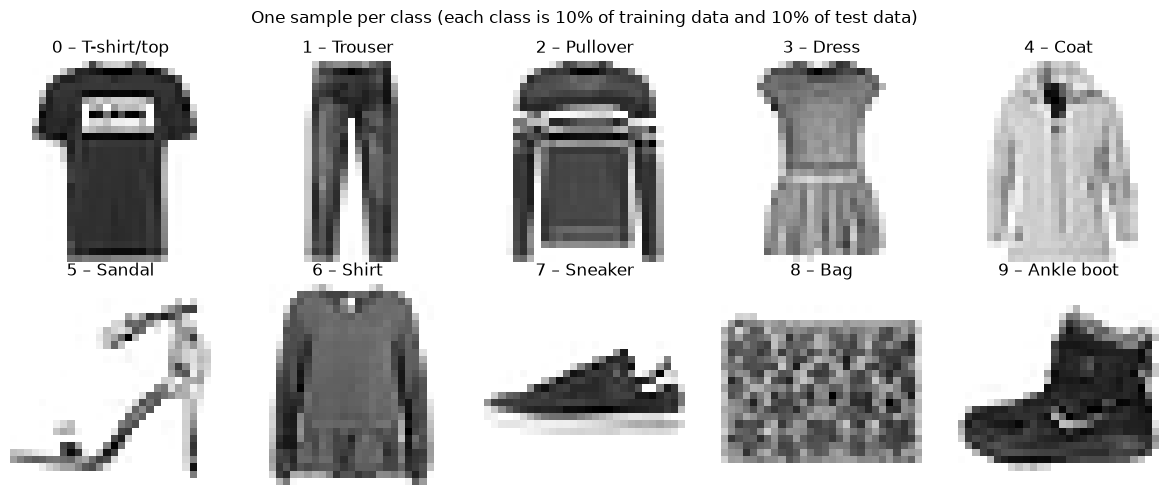

In [3]:
print(f"""The fashion_mnist dataset consists of {X_train.shape[0] + X_test.shape[0]} labeled {X_train.shape[1]}x{X_train.shape[2]}p grayscale images of fashion items.
The dataset is split up into four numpy arrays (X_train, y_train, X_test and y_test).

X_train and y_train make up the training set with {X_train.shape[0]} images, whereas X_test and y_test make up the test set with {X_test.shape[0]} images.

The input (X_train/X_test) is saved in a {X_test.ndim}-dimensional {type(X_test)}.
The first dimension can be understood as the id of the image and the 2nd and 3rd dimension store the 28x28p image.
A pixel has a value between {X_train.min()} and {X_test.max()}.

The label (y_train/y_test) is a {y_train.ndim}-dimensional {type(X_test)}. A label is a number between  {y_test.min()} and {y_test.max()}.
The numbers have the following meaning:""")
label_number, label_meaning = [0,1,2,3,4,5,6,7,8,9], ["T-shirt/top", "Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

for label in label_number:
    print(f"\t{label} = {label_meaning[label]}")

print("Now lets see one example for each of the different labels in addition to the distribution:")

#I'm now importing matplotlib to display the images and numpy for easier array navigation.
import matplotlib.pyplot as plt
import numpy as np


#Displaying an example image of each label in a 2 by 5 grid; AI supported
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for label, ax in zip(label_number, axes.flatten()):
    index = np.argmax(y_train == label)          # first image of this class
    ax.imshow(X_train[index], cmap="gray_r", interpolation="nearest")
    ax.set_title(f"{label} – {label_meaning[label]}")
    ax.axis("off")

fig.suptitle("One sample per class (each class is 10% of training data and 10% of test data)")
plt.tight_layout()
plt.show()

In [4]:
print("Now lets look at how the labels are distributed across the given data:")

#Here I calculate the distribution of the different labels:
distribution = np.empty((11,2))
for label in label_number:
    distribution[label][0] = np.argwhere(y_train == label).size
    distribution[label][1] = np.argwhere(y_test == label).size
distribution[10] = np.sum(distribution[:10], axis=0)

#Displaying the distributions; AI supported
header = f"{'Label':<6}{'Class':<13}{'Train':>7}{'Train %':>9}{'Test':>7}{'Test %':>9}"
print(header)
print("-" * len(header))

for i in range(11):
    if i == 10:
        print("-" * len(header))          # separator before the total row
    name  = label_meaning[i] if i < 10 else "Total"
    label = str(i) if i < 10 else ""
    train, test = distribution[i]
    train_pct = f"{train / distribution[10][0] * 100:.1f}%"
    test_pct  = f"{test  / distribution[10][1] * 100:.1f}%"
    print(f"{label:<6}{name:<13}{int(train):>7}{train_pct:>9}{int(test):>7}{test_pct:>9}")

print("It's clearly visible, that the labels are perfectly distributed across the whole dataset.")

Now lets look at how the labels are distributed across the given data:
Label Class          Train  Train %   Test   Test %
---------------------------------------------------
0     T-shirt/top     6000    10.0%   1000    10.0%
1     Trouser         6000    10.0%   1000    10.0%
2     Pullover        6000    10.0%   1000    10.0%
3     Dress           6000    10.0%   1000    10.0%
4     Coat            6000    10.0%   1000    10.0%
5     Sandal          6000    10.0%   1000    10.0%
6     Shirt           6000    10.0%   1000    10.0%
7     Sneaker         6000    10.0%   1000    10.0%
8     Bag             6000    10.0%   1000    10.0%
9     Ankle boot      6000    10.0%   1000    10.0%
---------------------------------------------------
      Total          60000   100.0%  10000   100.0%
It's clearly visible, that the labels are perfectly distributed across the whole dataset.


**1.2 - Normalisation**

As stated before each pixel has a value between 0 and 255.
To ensure faster convergence and a shorter training process I am now going to
normalize this range to be between 0.0 and 1.0.

This can be easily achieved by dividing each pixel value by 255.
    
I am going to put the normalized inputs into new arrays called "X_train_norm" and "X_test_norm":


In [5]:
X_train_norm = (X_train / 255.0).astype("float32") #.astype("float32") to save memory as Kera casts to float32 anyways - AI suggestion
X_test_norm = (X_test / 255.0).astype("float32")

To prove the normalization has worked I am now printing the same pixel value from
the regular test set and the new normalized test set:

In [6]:
#finding the first index where the pixel value is between 51 and 199 and saving it to prove_index
prove_index = np.unravel_index(np.argmax((X_train > 50) & (X_train < 200)), X_train.shape)

In [7]:
print(f"""In the first image of the test set the pixel [3][16] has a value of {X_train[prove_index]}
and in the new normalized test set it has a value of {X_train_norm[prove_index]}.
    
{X_train_norm[prove_index]} * 255 = 73 is a {X_train_norm[prove_index] * 255 == X_train[prove_index]} statement.

The normalization has worked.""")

In the first image of the test set the pixel [3][16] has a value of 73
and in the new normalized test set it has a value of 0.2862745225429535.

0.2862745225429535 * 255 = 73 is a True statement.

The normalization has worked.


**1.3 - Reshaping**

In order to feed the MLP and CNN, the input has to be reshaped in a specific way. Lets start with the MLP.

1.3.1 - Reshaping Data to feed **MLP**:

In [8]:
print(f"""Currently each input has a shape of {X_train[0].shape} because the pixels are saved in a 2-D array.
For the MLP we want the inputs to be a flat 1-D array with {28*28} cells.
For this we use the numpy reshape method:""")

Currently each input has a shape of (28, 28) because the pixels are saved in a 2-D array.
For the MLP we want the inputs to be a flat 1-D array with 784 cells.
For this we use the numpy reshape method:


In [9]:
X_train_MLP = X_train_norm.reshape(-1, 28 * 28)
X_test_MLP = X_test_norm.reshape(-1, 28 * 28)

In [10]:
print(f"The shape of an input for the MLP changed from {X_train[0].shape} to {X_train_MLP[0].shape}.")

The shape of an input for the MLP changed from (28, 28) to (784,).


1.3.2 - Reshaping Data to feed **CNN**:

CNNs expect images in an array form like we originally got it. But in addition
they also expect an additional "channel" information. Each channel stores the values of different colors per pixel.
Because our data is in a grayscale form, we can only offer a single channel. Again we use the numpy reshape tool
to reshape the data accordingly:

In [11]:
X_train_CNN = X_train_norm.reshape(-1, 28, 28, 1)
X_test_CNN = X_test_norm.reshape(-1, 28, 28, 1)

In [12]:
print(f"""The shape of an input for the CNN changed from {X_train[0].shape} to {X_train_CNN[0].shape},
with the additional 1 at the end being the channel.
Because I plan on using Keras instead of PyTorch, the channel is at the end.""")

The shape of an input for the CNN changed from (28, 28) to (28, 28, 1),
with the additional 1 at the end being the channel.
Because I plan on using Keras instead of PyTorch, the channel is at the end.


**1.4 - Train/validation split**

To monitor generalisation during training and to inform hyperparameter selection later in the process I am now going to carve out a validation set from the training set. To keep the numbers nice I have decided to take $\frac{1}{6}$ of the training data and turn it into the validation set.
Since the distribution of labels is perfectly equal in the training and test set, I will make sure the validation set also has an equal distribution of labels. I will be taking out the first 1000 pictures per label and move them into the validation set.
Another approach would be to choose 1000 inputs per label at random, but since the dataset is already shuffled, it is not necessary.

In [13]:
validation_set_indices = np.empty((10,1000), dtype=int) #stores the first thousand indices of each label for validation
training_set_indices = np.empty((50000), dtype=int) #stores the remaining indices for training

#collect the first thousand indices of each label
for label in label_number:
    validation_set_indices[label] = np.transpose(np.argwhere(y_train == label)[:1000])[0]
    
#flatten the array and sort it
validation_set_indices = np.sort(validation_set_indices.reshape(-1))

#put the indices which are not in the validation set into the training set.
#There is most likely a better way to do this with a mask, but I find it easier to follow this approach
index_train = 0
for i in range(0,60000):
    if not i in validation_set_indices:
        training_set_indices[index_train] = i
        index_train = index_train + 1


#now sorting indices in the corresponding data arrays with "_f" for final.
#I'm deliberatly creating some identical copies in order to have the variable names be consistent.

#MLP
X_train_MLP_f = X_train_MLP[training_set_indices]
y_train_MLP_f = y_train[training_set_indices]

X_validation_MLP_f = X_train_MLP[validation_set_indices]
y_validation_MLP_f = y_train[validation_set_indices]

X_test_MLP_f = X_test_MLP
y_test_MLP_f = y_test

#CNN
X_train_CNN_f = X_train_CNN[training_set_indices]
y_train_CNN_f = y_train[training_set_indices]

X_validation_CNN_f = X_train_CNN[validation_set_indices]
y_validation_CNN_f = y_train[validation_set_indices]

X_test_CNN_f = X_test_CNN
y_test_CNN_f = y_test

In [14]:
print(f"""We now have the following distribution for the MLP/CNN datasets:
Training set: \t\t{X_train_MLP_f.shape[0]} inputs, 5000 for each label
Validation set: \t{X_validation_MLP_f.shape[0]} inputs, 1000 for each label
Testing set: \t\t{X_test_MLP.shape[0]} inputs, 1000 for each label
""")

We now have the following distribution for the MLP/CNN datasets:
Training set: 		50000 inputs, 5000 for each label
Validation set: 	10000 inputs, 1000 for each label
Testing set: 		10000 inputs, 1000 for each label



The preparation of the data is now finalized and the variables are the following:<br>
**MLP-Data**:<br>
Training:<br>
&nbsp;&nbsp;X_train_MLP_f<br>
&nbsp;&nbsp;y_train_MLP_f<br>
Validation:<br>
&nbsp;&nbsp;X_validation_MLP_f<br>
&nbsp;&nbsp;y_validation_MLP_f<br>
Testing:<br>
&nbsp;&nbsp;X_test_MLP_f<br>
&nbsp;&nbsp;y_test_MLP_f<br>
<br>
**CNN-Data**:<br>
Training:<br>
&nbsp;&nbsp;X_train_CNN_f<br>
&nbsp;&nbsp;y_train_CNN_f<br>
Validation:<br>
&nbsp;&nbsp;X_validation_CNN_f<br>
&nbsp;&nbsp;y_validation_CNN_f<br>
Testing:<br>
&nbsp;&nbsp;X_test_CNN_f<br>
&nbsp;&nbsp;y_test_CNN_f<br>
    

**Summary of Task 1**:
With my approach I'm trying to make it as easy to follow as possible for the reader and myself included. This leads me to take some choices that waste a considerable amount of memory. But given the small size of the dataset, even my wasteful memory usage is not pushing any modern computer or server to its limits and therefore I have decided to stick to my approach.

***Task 2 — Model Training and Hyperparameter Tuning***

Now that the data is prepared it is time to make choices regarding the hyperparameters for the two models. For both the MLP and CNN I will perform a **Grid Search**. The grid search will go over 3 hyperparameters with three values each. This leads to $3^3 = 27$ combinations. I will be doing 50 epochs for each combination.<br>
The grid search will track the performance on the validation set for each of the combinations of hyperparameters in addition to the time it took to fit them on my computer. Tracking the time is not part of the task, but I'm curious if there is a correlation between training time and performance.

**2.1 - MLP**

For the MLP grid search the following hyperparameters will be **consistent**:<br>
Number of hidden layers: 3<br>
Activation function: ReLU<br>
Gradient descent: Adam<br>
The last layer has 10 neurons and softmax activation as instructed in the task.<br><br>

The hyperparameters that will **vary**:<br>
learning rate: 0.01; 0.001; 0.0001<br>
batch size: 64; 128; 256<br>
neurons per layer: 128; 256; 512

In [15]:
#Setting up a function for fitting a model with the fixed hyperparameters as described and the takes the variable hyperparameters as an argument
from tensorflow import keras
from tensorflow.keras import layers

def get_mlp_accuracy(learning_rate, batch_size, neurons_per_layer):
    tf.keras.utils.set_random_seed(1337) #makes the results reproducable
    
    model = keras.Sequential([
        layers.Input(shape=(784,)),    #input layer size
        layers.Dense(neurons_per_layer, activation="relu"),    #hidden layer 1
        layers.Dense(neurons_per_layer, activation="relu"),    #hidden layer 2
        layers.Dense(neurons_per_layer, activation="relu"),    #hidden layer 3
        layers.Dense(10, activation="softmax"),    #output layer
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        X_train_MLP_f, y_train_MLP_f,
        validation_data=(X_validation_MLP_f, y_validation_MLP_f),
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )
    return history


In [16]:
#setting up the hyper parameter grid
learning_rate_mlp = [0.01, 0.001, 0.0001]
batch_size_mlp = [64, 128, 256]
neurons_per_layer_mlp = [128, 256, 512]

results_mlp = [] #the results will be documented here

In [17]:
import time #to calculate the fitting time
import itertools #iterates through all the hyperparameter combination
import pandas as pd #pandas for displaying the results

# This is where the grid search switch comes into play
if run_real_grid_search:

    fitting_counter_mlp = 0 #simply for tracking progress during the fitting process

    for lr, bs, npl in itertools.product(learning_rate_mlp, batch_size_mlp, neurons_per_layer_mlp):

        #fitting a set of hyperparameters with timestamp before and after
        start_time = time.perf_counter()
        mlp_accuracy = get_mlp_accuracy(lr, bs, npl).history["val_accuracy"][-1]
        end_time = time.perf_counter()
        fit_time = int(end_time - start_time)

        #documenting the results
        results_mlp.append({"Learning_Rate": lr, "Batch_Size": bs, "Neurons_per_Layer": npl, "Model_Accuracy": mlp_accuracy, "Fitting_Time": fit_time})

        #grid search progress display
        fitting_counter_mlp += 1
        print(f"Finished fitting model with learning rate {lr}; batch size {bs}; neurons per layer {npl} in {fit_time} seconds. {fitting_counter_mlp}/27") #for progress tracking

    df_mlp = pd.DataFrame(results_mlp).sort_values("Model_Accuracy", ascending=False)

    total_fit_time_mlp = int(df_mlp["Fitting_Time"].sum())
    print(f"Total time to do the grid search: in seconds {total_fit_time_mlp}; in minutes {total_fit_time_mlp//60}; in hours {total_fit_time_mlp//60/60}")
else:
    hard_coded_results_MLP_grid_search = [{'Learning_Rate': 0.0001, 'Batch_Size': 64, 'Neurons_per_Layer': 128, 'Model_Accuracy': 0.8877000212669373, 'Fitting_Time': 108}, {'Learning_Rate': 0.001, 'Batch_Size': 256, 'Neurons_per_Layer': 512, 'Model_Accuracy': 0.8863999843597412, 'Fitting_Time': 186}, {'Learning_Rate': 0.0001, 'Batch_Size': 128, 'Neurons_per_Layer': 256, 'Model_Accuracy': 0.8858000040054321, 'Fitting_Time': 120}, {'Learning_Rate': 0.0001, 'Batch_Size': 128, 'Neurons_per_Layer': 128, 'Model_Accuracy': 0.8853999972343445, 'Fitting_Time': 71}, {'Learning_Rate': 0.001, 'Batch_Size': 256, 'Neurons_per_Layer': 256, 'Model_Accuracy': 0.8830000162124634, 'Fitting_Time': 88}, {'Learning_Rate': 0.001, 'Batch_Size': 128, 'Neurons_per_Layer': 512, 'Model_Accuracy': 0.8813999891281128, 'Fitting_Time': 234}, {'Learning_Rate': 0.0001, 'Batch_Size': 256, 'Neurons_per_Layer': 128, 'Model_Accuracy': 0.8805000185966492, 'Fitting_Time': 46}, {'Learning_Rate': 0.0001, 'Batch_Size': 128, 'Neurons_per_Layer': 512, 'Model_Accuracy': 0.8801000118255615, 'Fitting_Time': 227}, {'Learning_Rate': 0.001, 'Batch_Size': 64, 'Neurons_per_Layer': 256, 'Model_Accuracy': 0.8794000148773193, 'Fitting_Time': 170}, {'Learning_Rate': 0.0001, 'Batch_Size': 256, 'Neurons_per_Layer': 256, 'Model_Accuracy': 0.8784999847412109, 'Fitting_Time': 89}, {'Learning_Rate': 0.001, 'Batch_Size': 64, 'Neurons_per_Layer': 512, 'Model_Accuracy': 0.8783000111579895, 'Fitting_Time': 346}, {'Learning_Rate': 0.0001, 'Batch_Size': 64, 'Neurons_per_Layer': 512, 'Model_Accuracy': 0.8780999779701233, 'Fitting_Time': 348}, {'Learning_Rate': 0.001, 'Batch_Size': 128, 'Neurons_per_Layer': 256, 'Model_Accuracy': 0.8769999742507935, 'Fitting_Time': 118}, {'Learning_Rate': 0.01, 'Batch_Size': 256, 'Neurons_per_Layer': 128, 'Model_Accuracy': 0.8762000203132629, 'Fitting_Time': 54}, {'Learning_Rate': 0.0001, 'Batch_Size': 256, 'Neurons_per_Layer': 512, 'Model_Accuracy': 0.8759999871253967, 'Fitting_Time': 170}, {'Learning_Rate': 0.01, 'Batch_Size': 256, 'Neurons_per_Layer': 256, 'Model_Accuracy': 0.8756999969482422, 'Fitting_Time': 104}, {'Learning_Rate': 0.001, 'Batch_Size': 128, 'Neurons_per_Layer': 128, 'Model_Accuracy': 0.8747000098228455, 'Fitting_Time': 67}, {'Learning_Rate': 0.001, 'Batch_Size': 256, 'Neurons_per_Layer': 128, 'Model_Accuracy': 0.8734999895095825, 'Fitting_Time': 51}, {'Learning_Rate': 0.01, 'Batch_Size': 128, 'Neurons_per_Layer': 128, 'Model_Accuracy': 0.8733999729156494, 'Fitting_Time': 75}, {'Learning_Rate': 0.01, 'Batch_Size': 128, 'Neurons_per_Layer': 256, 'Model_Accuracy': 0.8723999857902527, 'Fitting_Time': 120}, {'Learning_Rate': 0.001, 'Batch_Size': 64, 'Neurons_per_Layer': 128, 'Model_Accuracy': 0.871399998664856, 'Fitting_Time': 112}, {'Learning_Rate': 0.01, 'Batch_Size': 256, 'Neurons_per_Layer': 512, 'Model_Accuracy': 0.871399998664856, 'Fitting_Time': 191}, {'Learning_Rate': 0.01, 'Batch_Size': 128, 'Neurons_per_Layer': 512, 'Model_Accuracy': 0.8708999752998352, 'Fitting_Time': 313}, {'Learning_Rate': 0.01, 'Batch_Size': 64, 'Neurons_per_Layer': 128, 'Model_Accuracy': 0.866100013256073, 'Fitting_Time': 194}, {'Learning_Rate': 0.0001, 'Batch_Size': 64, 'Neurons_per_Layer': 256, 'Model_Accuracy': 0.8640999794006348, 'Fitting_Time': 179}, {'Learning_Rate': 0.01, 'Batch_Size': 64, 'Neurons_per_Layer': 512, 'Model_Accuracy': 0.8623999953269958, 'Fitting_Time': 428}, {'Learning_Rate': 0.01, 'Batch_Size': 64, 'Neurons_per_Layer': 256, 'Model_Accuracy': 0.8537999987602234, 'Fitting_Time': 295}]
    df_mlp = pd.DataFrame(hard_coded_results_MLP_grid_search).sort_values("Model_Accuracy", ascending=False)


Lets look at the result of the grid search. I sorted it by accuracy of the model against the validation set.

In [18]:
print(df_mlp)

    Learning_Rate  Batch_Size  Neurons_per_Layer  Model_Accuracy  Fitting_Time
0          0.0001          64                128          0.8877           108
1          0.0010         256                512          0.8864           186
2          0.0001         128                256          0.8858           120
3          0.0001         128                128          0.8854            71
4          0.0010         256                256          0.8830            88
5          0.0010         128                512          0.8814           234
6          0.0001         256                128          0.8805            46
7          0.0001         128                512          0.8801           227
8          0.0010          64                256          0.8794           170
9          0.0001         256                256          0.8785            89
10         0.0010          64                512          0.8783           346
11         0.0001          64                512    

The hyperparameters that achieved the highest prediction accuracy of 88.77% on the validation set are:<br>
Learning rate: 0.0001<br>
Batch size: 64<br>
Neurons per layer: 128<br>
These hyperparameters will be used for subsequent evaluation in the rest of this notebook. So lets build a MLP with them:

In [19]:
def build_final_mlp():
    tf.keras.utils.set_random_seed(1337) #makes the results reproducable
    
    model = keras.Sequential([
        layers.Input(shape=(784,)),    #input layer size
        layers.Dense(128, activation="relu"),    #hidden layer 1
        layers.Dense(128, activation="relu"),    #hidden layer 2
        layers.Dense(128, activation="relu"),    #hidden layer 3
        layers.Dense(10, activation="softmax"),    #output layer
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        X_train_MLP_f, y_train_MLP_f,
        validation_data=(X_validation_MLP_f, y_validation_MLP_f),
        epochs=50,
        batch_size=64,
        verbose=0
    )
    return model, history

final_mlp, history_mlp_final = build_final_mlp()

Now here are the training and validationloss/accuracy curves for the final MLP with the best performing hyperparameters from the grid search:

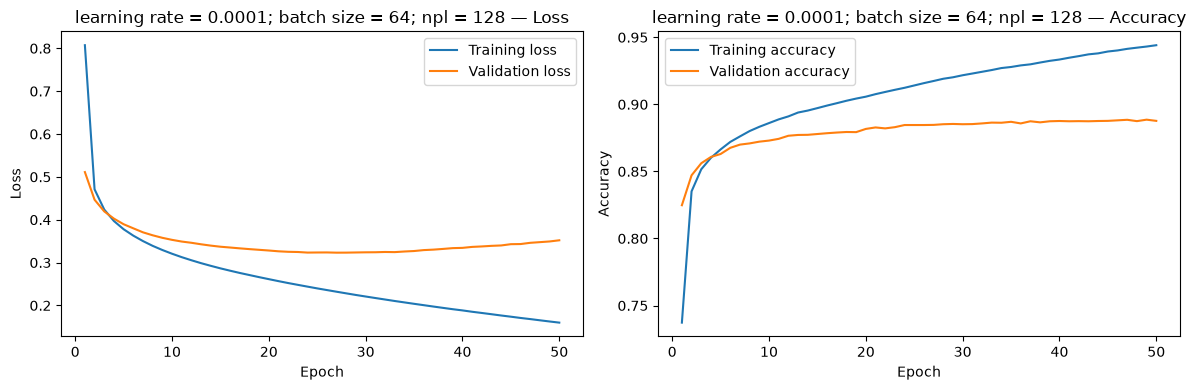

In [20]:
#function to plot the loss
import matplotlib.pyplot as plt

def plot_curves_mlp(history, title):
    epochs = range(1, len(history.history["loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(epochs, history.history["loss"],     label="Training loss")
    ax1.plot(epochs, history.history["val_loss"], label="Validation loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Loss"); ax1.legend()

    # Accuracy
    ax2.plot(epochs, history.history["accuracy"],     label="Training accuracy")
    ax2.plot(epochs, history.history["val_accuracy"], label="Validation accuracy")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} — Accuracy"); ax2.legend()

    plt.tight_layout()
    plt.show()

plot_curves_mlp(history_mlp_final, "learning rate = 0.0001; batch size = 64; npl = 128")

*Experimental Bonus:*<br>
Let's see if models that took longer to fit end up with a higher accuracy. This is not part of the task but I was wondering about it.
I'm drawing a scatterplot and the Pearson correlation coefficient with the model accuracy against the validation time and how long it took my machine to fit these models.

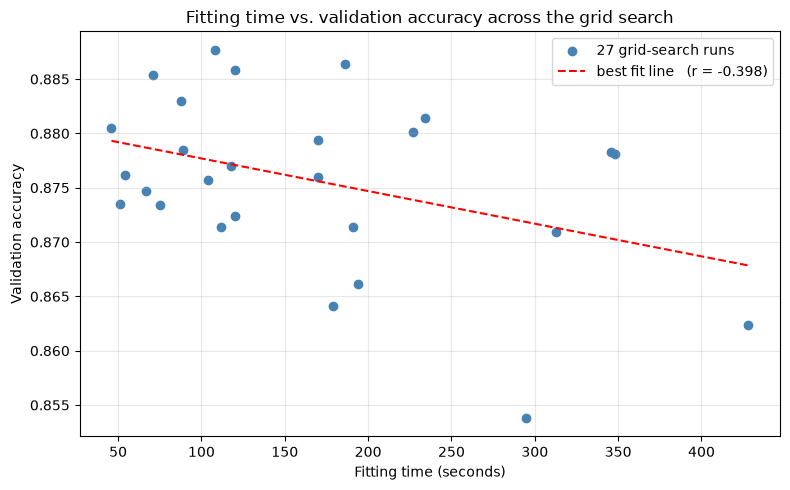

Pearson correlation coefficient: r = -0.398


In [21]:
import numpy as np
import matplotlib.pyplot as plt

def scatterplot_acc_time_mlp():
    x = df_mlp["Fitting_Time"].to_numpy(dtype=float)
    y = df_mlp["Model_Accuracy"].to_numpy(dtype=float)

    # Best-fit line: a degree-1 polynomial fit IS ordinary linear regression
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    # Pearson correlation coefficient (off-diagonal of the 2x2 correlation matrix)
    r = np.corrcoef(x, y)[0, 1]

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color="steelblue", label="27 grid-search runs")
    plt.plot(x_line, y_line, color="red", linestyle="--",
         label=f"best fit line   (r = {r:.3f})")
    plt.xlabel("Fitting time (seconds)")
    plt.ylabel("Validation accuracy")
    plt.title("Fitting time vs. validation accuracy across the grid search")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Pearson correlation coefficient: r = {r:.3f}")
    
scatterplot_acc_time_mlp()

A pcc of -0.398 can be interpreted as moderate negative correlation. Without going deep into this, it seems to me like the computationally expensive training sessions performed worse. Maybe this is caused by overfitting. But I'm not drawing conclusions from this, I was just curious. So take this with a grain of salt.

**2.2 - CNN**

For the CNN grid search the following hyperparameters will be **consistent**:<br>
Number of convolution layers: 3 (each have: zero padding, kernel size = 3, ReLU activation)<br>
Number of regular layers in connected head: 2 (first 128 neurons, ReLU activation; second 10 neurons, softmax activation for final classification)

Gradient descent: Adam<br>

The hyperparameters that will **vary**:<br>
learning rate: 0.01; 0.001; 0.0001<br>
batch size: 64; 128; 256<br>
filter sizes: (16, 32, 64); (32, 64, 128); (64, 128, 256)

In [22]:
# Setting up the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam

def get_cnn_accuracy(learning_rate, batch_size, start_filter):
    tf.keras.utils.set_random_seed(69) #makes the results reproducable
    
    model = Sequential([
        Input(shape=(28, 28, 1)),

        Conv2D(start_filter, kernel_size=3, padding="same", activation="relu"),
        MaxPooling2D(pool_size=2),

        Conv2D(start_filter*2, kernel_size=3, padding="same", activation="relu"),
        MaxPooling2D(pool_size=2),

        Conv2D(start_filter*2*2, kernel_size=3, padding="same", activation="relu"),
        MaxPooling2D(pool_size=2),

        # connected head
        Flatten(),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax"),
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    history = model.fit(
        X_train_CNN_f, y_train_CNN_f,
        validation_data=(X_validation_CNN_f, y_validation_CNN_f),
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )
    
    return history


In [23]:
learning_rate_cnn = [0.01, 0.001, 0.0001]
batch_size_cnn = [64, 128, 256]
start_filter_cnn = [16, 32, 64]

results_cnn = []

In [24]:
import time
import itertools
import pandas as pd

# Grid switch
if run_real_grid_search:
    fitting_counter_cnn = 0

    for lr, bs, sf in itertools.product(learning_rate_cnn, batch_size_cnn, start_filter_cnn):

        start_time = time.perf_counter()
        model_accuracy = get_cnn_accuracy(lr, bs, sf).history["val_accuracy"][-1]
        end_time = time.perf_counter()
        fit_time = int(end_time - start_time)
    
        results_cnn.append({"Learning_Rate": lr, "Batch_Size": bs, "Filter Setup": f"{sf};{sf*2};{sf*2*2}", "Model_Accuracy": model_accuracy, "Fitting_Time": fit_time})

        fitting_counter_cnn += 1
        print(f"Finished fitting model with learning rate {lr}; batch size {bs}; filter setup {sf};{sf*2};{sf*2*2} in {fit_time} seconds. {fitting_counter_cnn}/27")

    df_cnn = pd.DataFrame(results_cnn).sort_values("Model_Accuracy", ascending=False)

    total_fit_time_cnn = int(df_cnn["Fitting_Time"].sum())
    print(f"Total time to do the grid search: in seconds {total_fit_time_cnn}; in minutes {total_fit_time_cnn//60}; in hours {total_fit_time_cnn//60/60}")
else:
    hard_coded_results_cnn_grid_search = [{'Learning_Rate': 0.0001, 'Batch_Size': 256, 'Filter Setup': '64;128;256', 'Model_Accuracy': 0.9205999970436096, 'Fitting_Time': 1768}, {'Learning_Rate': 0.001, 'Batch_Size': 64, 'Filter Setup': '64;128;256', 'Model_Accuracy': 0.9204999804496765, 'Fitting_Time': 2080}, {'Learning_Rate': 0.001, 'Batch_Size': 128, 'Filter Setup': '64;128;256', 'Model_Accuracy': 0.9200000166893005, 'Fitting_Time': 1903}, {'Learning_Rate': 0.0001, 'Batch_Size': 128, 'Filter Setup': '64;128;256', 'Model_Accuracy': 0.9199000000953674, 'Fitting_Time': 1848}, {'Learning_Rate': 0.001, 'Batch_Size': 128, 'Filter Setup': '32;64;128', 'Model_Accuracy': 0.9178000092506409, 'Fitting_Time': 667}, {'Learning_Rate': 0.001, 'Batch_Size': 64, 'Filter Setup': '32;64;128', 'Model_Accuracy': 0.9154000282287598, 'Fitting_Time': 768}, {'Learning_Rate': 0.001, 'Batch_Size': 256, 'Filter Setup': '64;128;256', 'Model_Accuracy': 0.914900004863739, 'Fitting_Time': 1800}, {'Learning_Rate': 0.0001, 'Batch_Size': 64, 'Filter Setup': '32;64;128', 'Model_Accuracy': 0.913100004196167, 'Fitting_Time': 795}, {'Learning_Rate': 0.0001, 'Batch_Size': 128, 'Filter Setup': '32;64;128', 'Model_Accuracy': 0.9125000238418579, 'Fitting_Time': 695}, {'Learning_Rate': 0.0001, 'Batch_Size': 256, 'Filter Setup': '32;64;128', 'Model_Accuracy': 0.911300003528595, 'Fitting_Time': 597}, {'Learning_Rate': 0.001, 'Batch_Size': 256, 'Filter Setup': '32;64;128', 'Model_Accuracy': 0.9099000096321106, 'Fitting_Time': 635}, {'Learning_Rate': 0.0001, 'Batch_Size': 64, 'Filter Setup': '16;32;64', 'Model_Accuracy': 0.9093000292778015, 'Fitting_Time': 412}, {'Learning_Rate': 0.001, 'Batch_Size': 128, 'Filter Setup': '16;32;64', 'Model_Accuracy': 0.9085999727249146, 'Fitting_Time': 290}, {'Learning_Rate': 0.001, 'Batch_Size': 256, 'Filter Setup': '16;32;64', 'Model_Accuracy': 0.9060999751091003, 'Fitting_Time': 239}, {'Learning_Rate': 0.001, 'Batch_Size': 64, 'Filter Setup': '16;32;64', 'Model_Accuracy': 0.9057000279426575, 'Fitting_Time': 393}, {'Learning_Rate': 0.0001, 'Batch_Size': 128, 'Filter Setup': '16;32;64', 'Model_Accuracy': 0.9056000113487244, 'Fitting_Time': 310}, {'Learning_Rate': 0.0001, 'Batch_Size': 64, 'Filter Setup': '64;128;256', 'Model_Accuracy': 0.9039999842643738, 'Fitting_Time': 2156}, {'Learning_Rate': 0.01, 'Batch_Size': 256, 'Filter Setup': '32;64;128', 'Model_Accuracy': 0.8996999859809875, 'Fitting_Time': 606}, {'Learning_Rate': 0.01, 'Batch_Size': 256, 'Filter Setup': '64;128;256', 'Model_Accuracy': 0.8968999981880188, 'Fitting_Time': 1708}, {'Learning_Rate': 0.0001, 'Batch_Size': 256, 'Filter Setup': '16;32;64', 'Model_Accuracy': 0.896399974822998, 'Fitting_Time': 227}, {'Learning_Rate': 0.01, 'Batch_Size': 128, 'Filter Setup': '32;64;128', 'Model_Accuracy': 0.895799994468689, 'Fitting_Time': 640}, {'Learning_Rate': 0.01, 'Batch_Size': 64, 'Filter Setup': '16;32;64', 'Model_Accuracy': 0.895799994468689, 'Fitting_Time': 402}, {'Learning_Rate': 0.01, 'Batch_Size': 256, 'Filter Setup': '16;32;64', 'Model_Accuracy': 0.8939999938011169, 'Fitting_Time': 228}, {'Learning_Rate': 0.01, 'Batch_Size': 128, 'Filter Setup': '16;32;64', 'Model_Accuracy': 0.8927000164985657, 'Fitting_Time': 288}, {'Learning_Rate': 0.01, 'Batch_Size': 64, 'Filter Setup': '64;128;256', 'Model_Accuracy': 0.8830999732017517, 'Fitting_Time': 2069}, {'Learning_Rate': 0.01, 'Batch_Size': 128, 'Filter Setup': '64;128;256', 'Model_Accuracy': 0.8765000104904175, 'Fitting_Time': 1835}, {'Learning_Rate': 0.01, 'Batch_Size': 64, 'Filter Setup': '32;64;128', 'Model_Accuracy': 0.8666999936103821, 'Fitting_Time': 752}]
    df_cnn = pd.DataFrame(hard_coded_results_cnn_grid_search).sort_values("Model_Accuracy", ascending=False)


Lets see the results of this grid search. It is again sorted by accuracy against validation set.

In [25]:
print(df_cnn)

    Learning_Rate  Batch_Size Filter Setup  Model_Accuracy  Fitting_Time
0          0.0001         256   64;128;256          0.9206          1768
1          0.0010          64   64;128;256          0.9205          2080
2          0.0010         128   64;128;256          0.9200          1903
3          0.0001         128   64;128;256          0.9199          1848
4          0.0010         128    32;64;128          0.9178           667
5          0.0010          64    32;64;128          0.9154           768
6          0.0010         256   64;128;256          0.9149          1800
7          0.0001          64    32;64;128          0.9131           795
8          0.0001         128    32;64;128          0.9125           695
9          0.0001         256    32;64;128          0.9113           597
10         0.0010         256    32;64;128          0.9099           635
11         0.0001          64     16;32;64          0.9093           412
12         0.0010         128     16;32;64         

The hyperparameters that achieved the highest prediction accuracy of 92.06% on the validation set are:<br>
Learning rate: 0.0001<br>
Batch size: 256<br>
Filter setup: 64; 128; 256<br>
These hyperparameters will be used for subsequent evaluation in the rest of this notebook. So lets build a CNN with them:

In [26]:
def build_final_cnn():
    tf.keras.utils.set_random_seed(69) #makes the results reproducable
    
    model = Sequential([
        Input(shape=(28, 28, 1)),

        Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        MaxPooling2D(pool_size=2),

        Conv2D(128, kernel_size=3, padding="same", activation="relu"),
        MaxPooling2D(pool_size=2),

        Conv2D(256, kernel_size=3, padding="same", activation="relu"),
        MaxPooling2D(pool_size=2),

        # connected head
        Flatten(),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax"),
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    history = model.fit(
        X_train_CNN_f, y_train_CNN_f,
        validation_data=(X_validation_CNN_f, y_validation_CNN_f),
        epochs=50,
        batch_size=256,
        verbose=0
    )
    
    return model, history

final_cnn, history_cnn_final = build_final_cnn()

Now here are the training and validationloss/accuracy curves for the final CNN with the best performing hyperparameters from the grid search:

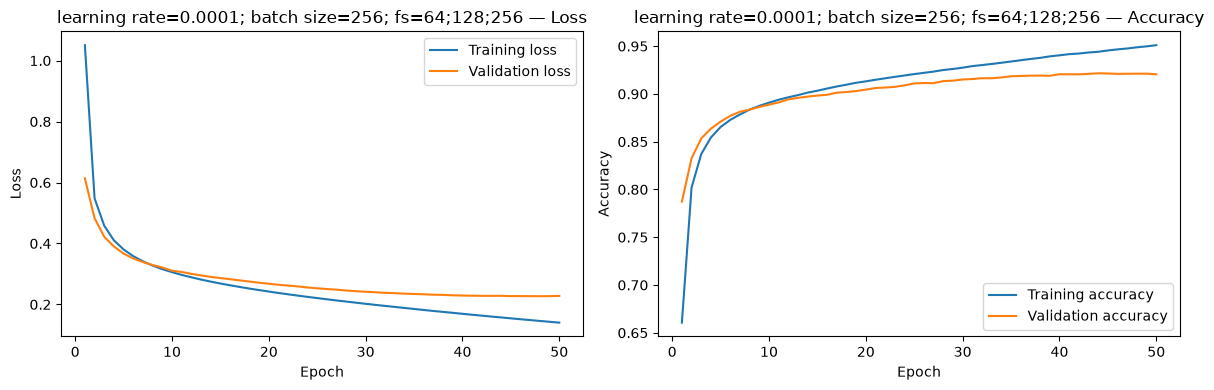

In [27]:
#function to plot the loss
import matplotlib.pyplot as plt

def plot_curves_cnn(history, title):
    epochs = range(1, len(history.history["loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(epochs, history.history["loss"],     label="Training loss")
    ax1.plot(epochs, history.history["val_loss"], label="Validation loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Loss"); ax1.legend()

    # Accuracy
    ax2.plot(epochs, history.history["accuracy"],     label="Training accuracy")
    ax2.plot(epochs, history.history["val_accuracy"], label="Validation accuracy")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} — Accuracy"); ax2.legend()

    plt.tight_layout()
    plt.show()

plot_curves_cnn(history_cnn_final, "learning rate=0.0001; batch size=256; fs=64;128;256")

*Experimental Bonus:*

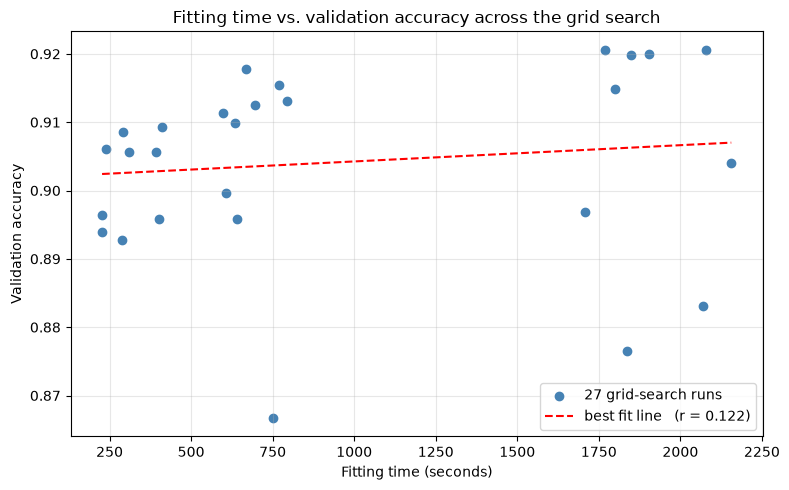

Pearson correlation coefficient: r = 0.122


In [28]:
import numpy as np
import matplotlib.pyplot as plt

def scatterplot_acc_time_cnn():
    x = df_cnn["Fitting_Time"].to_numpy(dtype=float)
    y = df_cnn["Model_Accuracy"].to_numpy(dtype=float)
    
    # Best-fit line: a degree-1 polynomial fit IS ordinary linear regression
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    
    # Pearson correlation coefficient (off-diagonal of the 2x2 correlation matrix)
    r = np.corrcoef(x, y)[0, 1]

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color="steelblue", label="27 grid-search runs")
    plt.plot(x_line, y_line, color="red", linestyle="--",
         label=f"best fit line   (r = {r:.3f})")
    plt.xlabel("Fitting time (seconds)")
    plt.ylabel("Validation accuracy")
    plt.title("Fitting time vs. validation accuracy across the grid search")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Pearson correlation coefficient: r = {r:.3f}")

scatterplot_acc_time_cnn()

For the CNN the pcc is only at 0.122 which is a very low amount. So there is no meaningful or only a very low positive correlation between computational complexity and model performance. Maybe this means that CNNs are less prone to overfitting? Take it with a grain of salt again.

***Task 3 — Evaluation on the Standard Test Set***

Now that we have decided on the final hyperparameters it is time to see how our final MLP and CNN models perform on our real test set.

In [29]:
# Evaluate each final model ONCE on the untouched test set.
mlp_test_loss, mlp_test_acc = final_mlp.evaluate(X_test_MLP_f, y_test_MLP_f, verbose=0)
cnn_test_loss, cnn_test_acc = final_cnn.evaluate(X_test_CNN_f, y_test_CNN_f, verbose=0)

print(f"{'Model':<6}{'Test loss':>12}{'Test accuracy':>16}")
print(f"{'MLP':<6}{mlp_test_loss:>12.4f}{mlp_test_acc:>16.4f}")
print(f"{'CNN':<6}{cnn_test_loss:>12.4f}{cnn_test_acc:>16.4f}")


Model    Test loss   Test accuracy
MLP         0.3786          0.8797
CNN         0.2587          0.9117


The CNN, with an accuracy on the test set with 91.17% clearly performs better than the MLP, which only correctly predicted 87.97% of the test set labels.

Lets look at a Confusion Matrix:

In [30]:
# Reusable function for confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


def plot_confusion_matrices(mlp_model, cnn_model, X_mlp, X_cnn, y_true,
                            context="test set",
                            class_names=("T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                                         "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot")):
    class_names = list(class_names)

    # predicted class = argmax over the 10 softmax outputs
    y_pred_mlp = mlp_model.predict(X_mlp, verbose=0).argmax(axis=1)
    y_pred_cnn = cnn_model.predict(X_cnn, verbose=0).argmax(axis=1)

    # accuracy computed from the predictions -> always matches the matrix shown
    acc_mlp = (y_pred_mlp == y_true).mean()
    acc_cnn = (y_pred_cnn == y_true).mean()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, y_pred, name, acc in [(axes[0], y_pred_mlp, "MLP", acc_mlp),
                                  (axes[1], y_pred_cnn, "CNN", acc_cnn)]:
        cm = confusion_matrix(y_true, y_pred, normalize="true")
        ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
            ax=ax, cmap="Greens", colorbar=False, xticks_rotation=45, values_format=".2f")
        ax.set_title(f"{name} — {context} (accuracy {acc:.3f})")
    plt.tight_layout()
    plt.show()

    return y_pred_mlp, y_pred_cnn

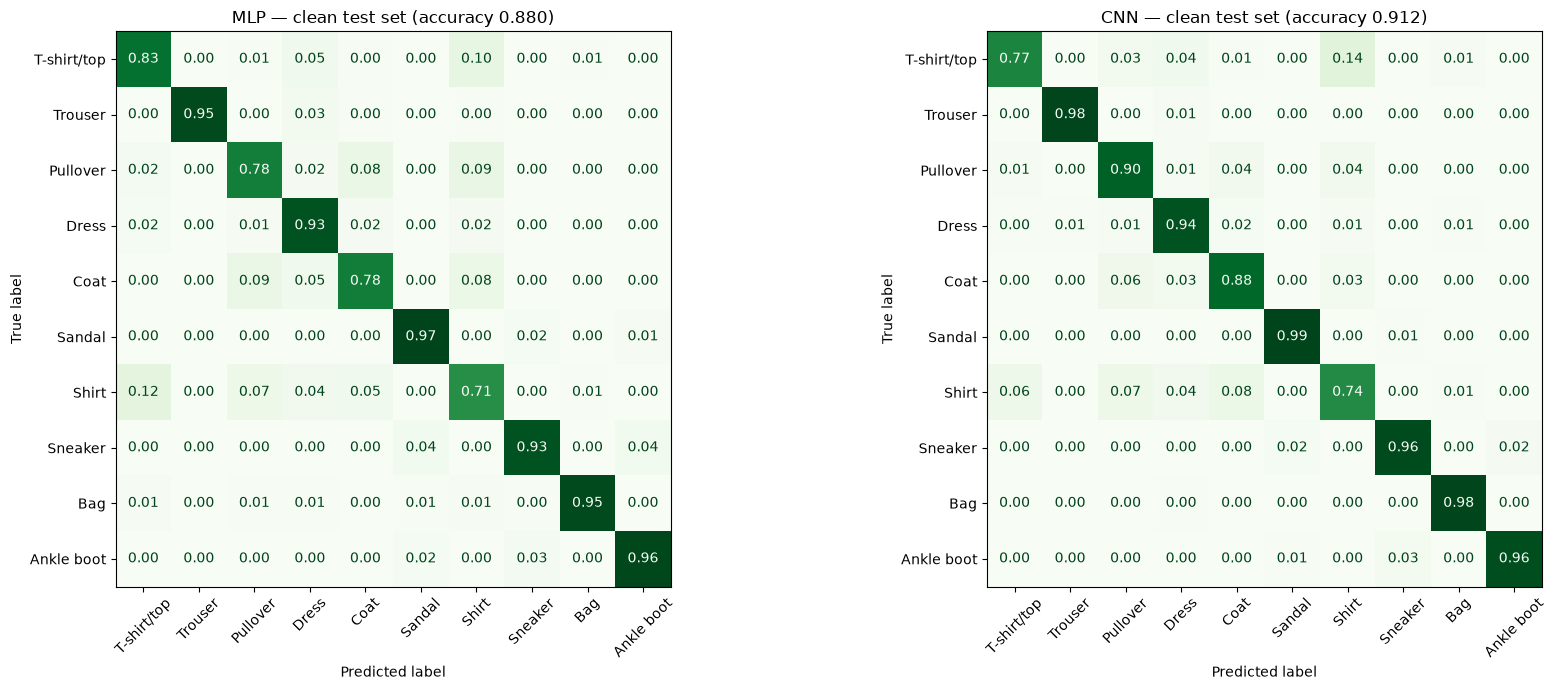


Top 5 confusions for the MLP (count: true -> predicted):
   123   Shirt        -> T-shirt/top
   104   T-shirt/top  -> Shirt
    88   Pullover     -> Shirt
    86   Coat         -> Pullover
    84   Pullover     -> Coat

Top 5 confusions for the CNN (count: true -> predicted):
   138   T-shirt/top  -> Shirt
    78   Shirt        -> Coat
    68   Shirt        -> Pullover
    62   Shirt        -> T-shirt/top
    58   Coat         -> Pullover


In [31]:
# calling confusion matrix with the original test set
y_pred_mlp, y_pred_cnn = plot_confusion_matrices(
    final_mlp, final_cnn, X_test_MLP_f, X_test_CNN_f, y_test,
    context="clean test set")

def top_confusions(y_true, y_pred, k=5,
                   class_names=("T-shirt/top","Trouser","Pullover","Dress","Coat",
                                "Sandal","Shirt","Sneaker","Bag","Ankle boot")):
    class_names = list(class_names)
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0)                      # ignore correct predictions
    pairs = [(cm[i, j], class_names[i], class_names[j])
             for i in range(10) for j in range(10) if cm[i, j] > 0]
    pairs.sort(reverse=True)
    return pairs[:k]

# printing the top 5 confusions of each model
for name, y_pred in [("MLP", y_pred_mlp), ("CNN", y_pred_cnn)]:
    print(f"\nTop 5 confusions for the {name} (count: true -> predicted):")
    for count, true_c, pred_c in top_confusions(y_test, y_pred):
        print(f"  {count:>4}   {true_c:<12} -> {pred_c}")

It is quite clear that both models tend to confuse T-shirts with shirts. I find it interesting however, that given the overall better performance of the CNN, it is the model with the highest amount of confusions (138 vs 123 in the MLP) in a single cell of the confusion matrix (it confused a T-shirt with a shirt 138 times).

***Task 4 — Robustness and Invariance Analysis***

Now we want to test how both the MLP and CNN model perform after we transform the image data. We will be using the exact models evaluated in task 3.

**4.1 - Create transformed test set**

The transformation will be simple. All test images will be shifted by two pixels to the right and two pixels down using the provided function in the task.

In [32]:
from scipy.ndimage import shift

def shift_images(images, shift_y=2, shift_x=2):
  return np.array([
    shift(img, shift=(shift_y, shift_x), mode="constant", cval=0.0)
    for img in images
  ])

I will use the already normalized test data "X_test_norm" from 1.2 as a starting point.

In [33]:
X_test_norm_shifted = shift_images(X_test_norm)

Let's print one image from X_test_norm and one from X_test_norm_shifted to see if it worked:

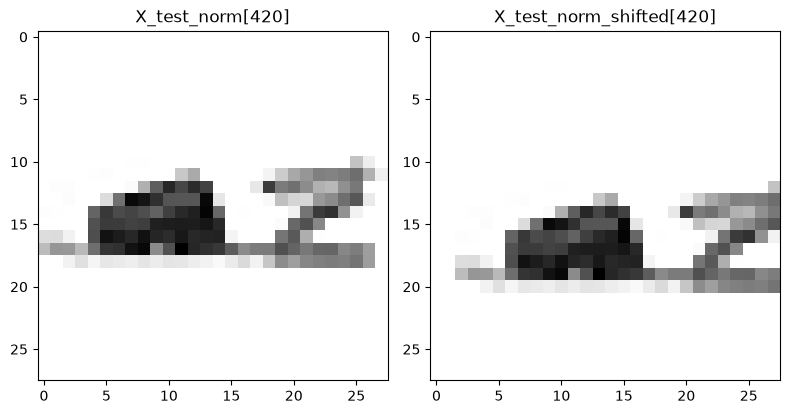

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Original image
axes[0].imshow(X_test_norm[420], cmap="gray_r", interpolation="nearest")
axes[0].set_title("X_test_norm[420]")

# Shifted image
axes[1].imshow(X_test_norm_shifted[420], cmap="gray_r", interpolation="nearest")
axes[1].set_title("X_test_norm_shifted[420]")

plt.tight_layout()
plt.show()

It worked. Now I will perform the data preparation for the MLP and CNN just as I did in task 1.3.

In [35]:
X_test_MLP_shifted = X_test_norm_shifted.reshape(-1, 28 * 28)
X_test_CNN_shifted = X_test_norm_shifted.reshape(-1, 28, 28, 1)

Now we have finished transforming the new transformed set and can see how our existing models perform on it.

**4.2 - Performance test on MLP and CNN**

I will be using the same metrics as I used in task 3. So let's start:

In [36]:
# Evaluate each final model on the transformed test set
mlp_test_loss, mlp_test_acc = final_mlp.evaluate(X_test_MLP_shifted, y_test_MLP_f, verbose=0)
cnn_test_loss, cnn_test_acc = final_cnn.evaluate(X_test_CNN_shifted, y_test_CNN_f, verbose=0)

print(f"{'Model':<6}{'Test loss':>12}{'Test accuracy':>16}")
print(f"{'MLP':<6}{mlp_test_loss:>12.4f}{mlp_test_acc:>16.4f}")
print(f"{'CNN':<6}{cnn_test_loss:>12.4f}{cnn_test_acc:>16.4f}")

Model    Test loss   Test accuracy
MLP         3.4280          0.3861
CNN         0.9994          0.6816


Our MLP predicts 38.61% of the shifted labels correctly, while the CNN predicts 68.16% correctly.

Confusion Matrix:

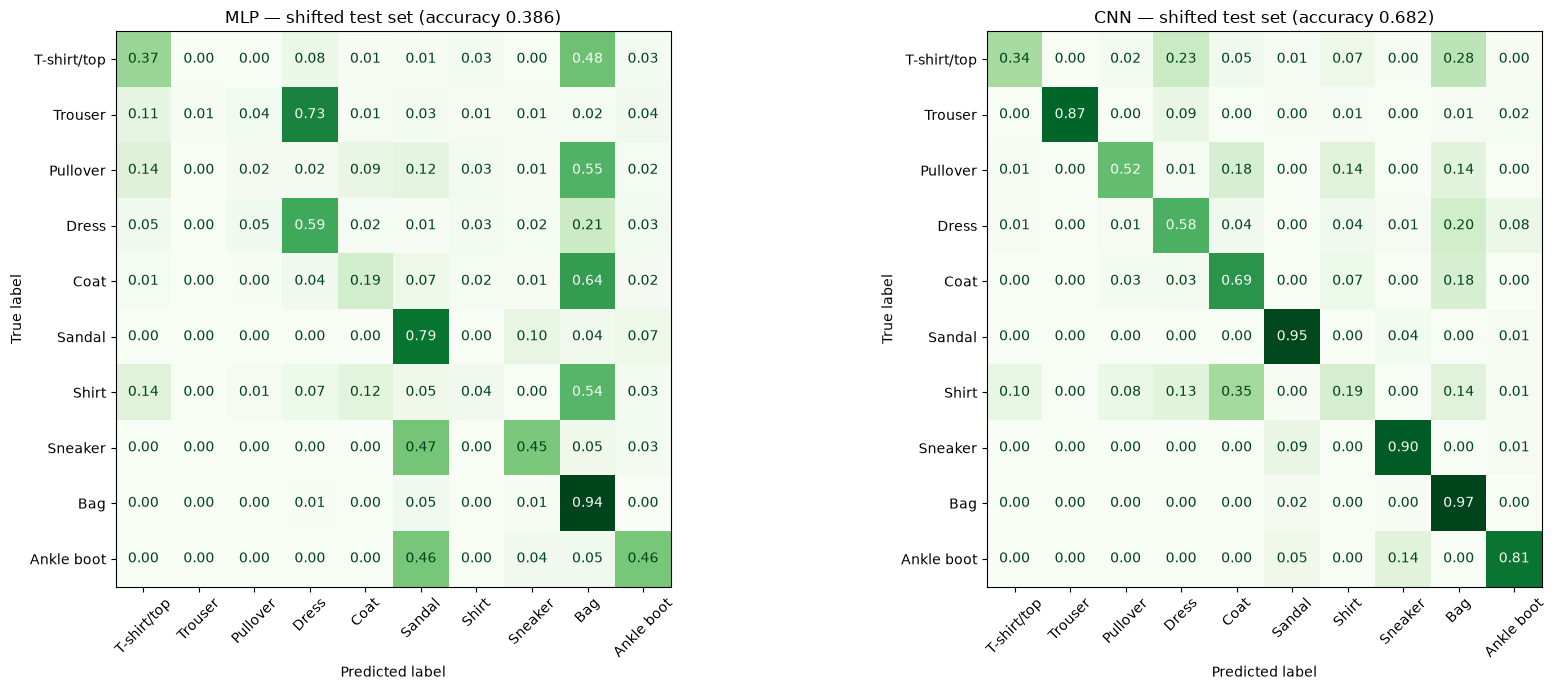

In [37]:
y_pred_mlp_shift, y_pred_cnn_shift = plot_confusion_matrices(
    final_mlp, final_cnn, X_test_MLP_shifted, X_test_CNN_shifted, y_test,
    context="shifted test set")

A lot of clothing items now look more like a bag to the MLP...

**4.3 - Comparison between MLP and CNN on transformed test set**

Given the relatively tiny transformation I think the drop in performance is enormous.<br>
The MLP now only correctly predicts 38.61% of the labels, which is less than half of what it correctly predicted before. However it is still a lot better than guessing the labels, which would lead to an average of 10%.<br>
The CNN predicts 68% of the shifted labels correctly. While still a huge drop in performance, it is predicting almost twice as many labels correctly, when compared with the MLP.

*The Bag mystery:*<br>
The bag really stands out in my opinion. Both the MLP and the CNN seem to label a lot of images as "bag" after the shift. Lets get some real numbers:

In [38]:
bag = 8  # "Bag"

mlp_bag = (y_pred_mlp_shift == bag).sum()
cnn_bag = (y_pred_cnn_shift == bag).sum()


for name, y_pred in [("MLP", y_pred_mlp_shift), ("CNN", y_pred_cnn_shift)]:
    predicted_bag = (y_pred == bag)
    correct   = (predicted_bag & (y_test == bag)).sum()   # said Bag, was Bag
    incorrect = (predicted_bag & (y_test != bag)).sum()   # said Bag, wasn't Bag
    print(f"{name}: predicted 'Bag' {predicted_bag.sum()} times "
          f"({correct} correct, {incorrect} wrong)")

MLP: predicted 'Bag' 3516 times (939 correct, 2577 wrong)
CNN: predicted 'Bag' 1913 times (968 correct, 945 wrong)


35.16% of every prediction from the MLP and 19,13% of the CNN are "bag". Interestingly enough, it still didn't label some actual bags as bag. Lets see three correctly labeled bags and three bags, that the MLP/CNN correctly identified before the shift, but wrongly identified after:

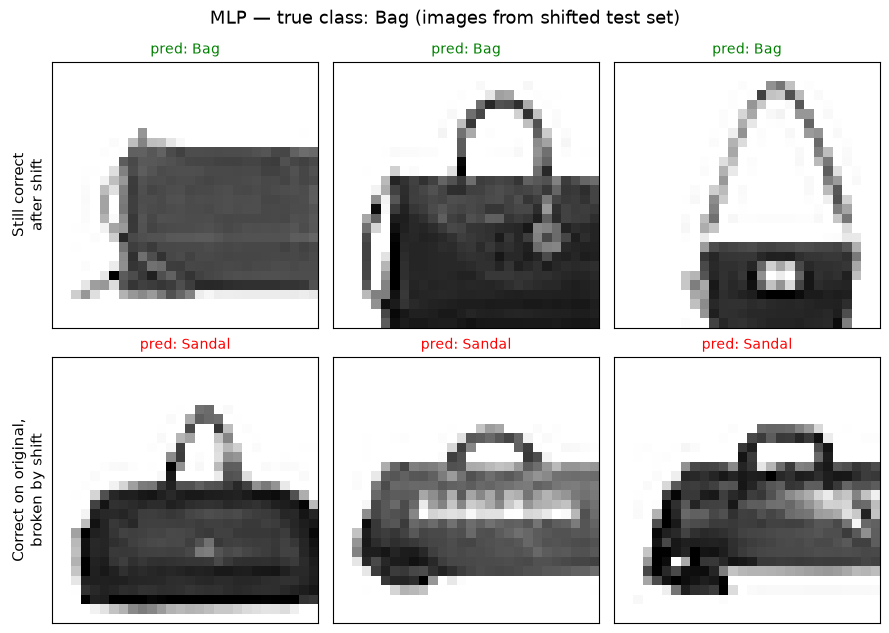

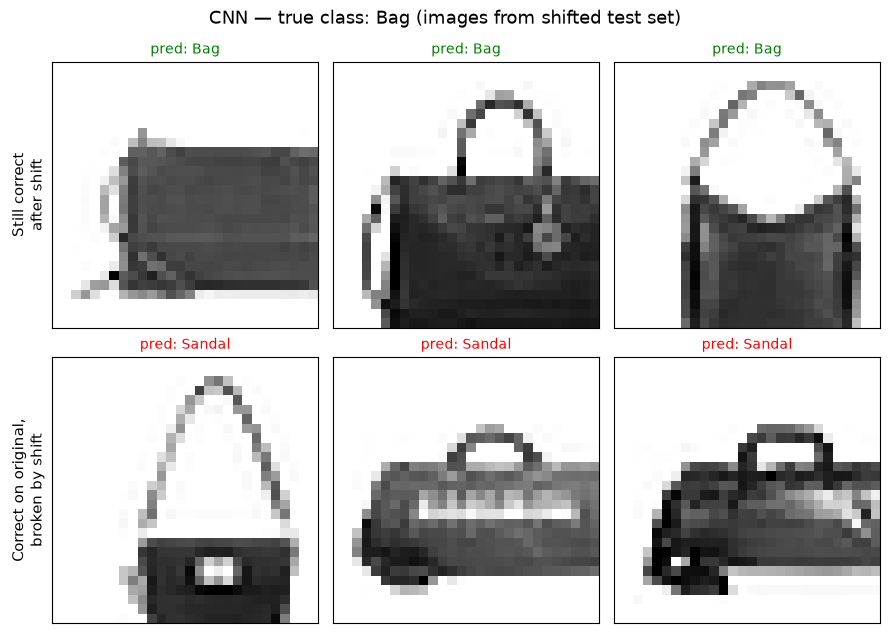

In [39]:
# code to display images of bags that have been correctly identified in the original test set, but wrongly identified
# in the shifted test set
import numpy as np
import matplotlib.pyplot as plt

def show_bag_grid(y_pred_clean, y_pred_shift, y_true, images, model_name,
                  bag=8,
                  class_names=("T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot")):
    class_names = list(class_names)

    # top: true Bag AND still correct on the shifted set
    correct_idx = np.where((y_true == bag) & (y_pred_shift == bag))[0][:3]
    # bottom: true Bag, correct on the ORIGINAL set but wrong on the shifted set
    broken_idx  = np.where((y_true == bag) & (y_pred_clean == bag) & (y_pred_shift != bag))[0][:3]

    fig, axes = plt.subplots(2, 3, figsize=(9, 6.5))

    for row, (idxs, color) in enumerate([(correct_idx, "green"), (broken_idx, "red")]):
        for col in range(3):
            ax = axes[row, col]
            ax.set_xticks([]); ax.set_yticks([])
            if col < len(idxs):
                idx = idxs[col]
                ax.imshow(images[idx], cmap="gray_r", interpolation="nearest")
                ax.set_title(f"pred: {class_names[y_pred_shift[idx]]}", color=color, fontsize=10)
            else:
                ax.axis("off")   # in case fewer than 3 exist

    axes[0, 0].set_ylabel("Still correct\nafter shift", fontsize=11)
    axes[1, 0].set_ylabel("Correct on original,\nbroken by shift", fontsize=11)
    fig.suptitle(f"{model_name} — true class: Bag (images from shifted test set)", fontsize=13)
    plt.tight_layout()
    plt.show()

show_bag_grid(y_pred_mlp, y_pred_mlp_shift, y_test, X_test_norm_shifted, "MLP")
show_bag_grid(y_pred_cnn, y_pred_cnn_shift, y_test, X_test_norm_shifted, "CNN")

I'm not sure what to read from this, but it's an interesting insight into the decision making of these models, because personally I wouldn't consider these edge cases.

I'm also interested in the change of the confusion matrix from original test set to shifted test set. So let's see another confusion matrix, where the deltas of the predictions between the original test set and the shifted test set are clearly visible. 

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_delta(mlp_model, cnn_model,
                         X_mlp_clean, X_cnn_clean,
                         X_mlp_shift, X_cnn_shift,
                         y_true,
                         class_names=("T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                                      "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot")):
    class_names = list(class_names)

    def delta_cm(model, X_clean, X_shift):
        p_clean = model.predict(X_clean, verbose=0).argmax(axis=1)
        p_shift = model.predict(X_shift, verbose=0).argmax(axis=1)
        cm_clean = confusion_matrix(y_true, p_clean, normalize="true")
        cm_shift = confusion_matrix(y_true, p_shift, normalize="true")
        return cm_shift - cm_clean

    deltas = {"MLP": delta_cm(mlp_model, X_mlp_clean, X_mlp_shift),
              "CNN": delta_cm(cnn_model, X_cnn_clean, X_cnn_shift)}
    totals = {name: np.abs(d).sum() for name, d in deltas.items()}   # L1 total absolute change

    vmax = max(np.abs(d).max() for d in deltas.values())

    fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
    for ax, (name, d) in zip(axes, deltas.items()):
        im = ax.imshow(d, cmap="coolwarm", vmin=-vmax, vmax=vmax)
        ax.set_xticks(range(10)); ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticks(range(10)); ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
        ax.set_title(f"{name} — confusion delta (shifted − clean)")
        for i in range(10):
            for j in range(10):
                if abs(d[i, j]) >= 0.01:
                    ax.text(j, i, f"{d[i, j]:+.2f}", ha="center", va="center", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        # the requested number, printed under the matrix
        ax.text(0.5, -0.32, f"Total absolute change (Manhattan Norm) = {totals[name]:.3f}",
                transform=ax.transAxes, ha="center", va="top",
                fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()
    return deltas, totals

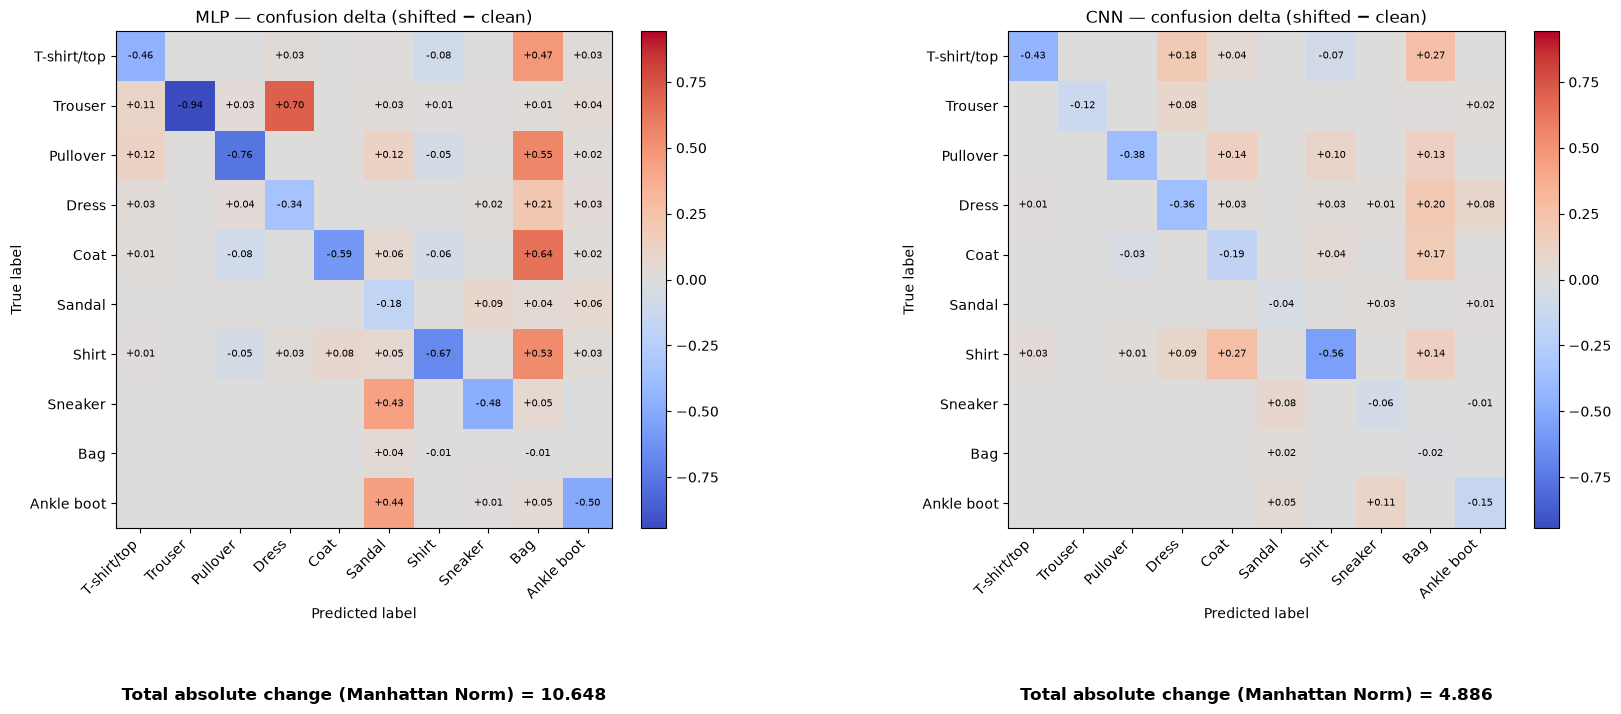

In [41]:
deltas = plot_confusion_delta(
    final_mlp, final_cnn,
    X_test_MLP_f, X_test_CNN_f,               # clean
    X_test_MLP_shifted, X_test_CNN_shifted,   # shifted
    y_test)

Numbers less than 0 (blue) point out a decrease from original to shifted test set, whereas numbers above 0 (red) indicate an increase.<br>
This matrix makes it very clear, that the correct predictions (the diagonal) decreased in both the MLP and CNN, though a lot more in the MLP.<br>
The increase in popularity of predicting images wrongly as "Bag" for both models also stands out.<br>
Another outlier, in the MLP only, is the "Trouser" being incorrectly labeled as "Dress". Before the shift the MLP correctly identified 95% of "Trousers", which was one of the strongest predictions actually. But after shifting the images about 70 % (so 700) images of "Trousers" now get wrongly identified as a "Dress".<br>
The *Manhattan Norm*, which adds up all the amount of deltas is a single number to compare the performance of the two models after the images have been shifted. The MLPs Manhattan Norm is more than twice as high as the one of the CNN.<br>
The matrix in combination with the Manhattan Norm can bring one to the conclusion, that the MLP gets a lot more confused by shifting the images, than the CNN does.

***Task 5 — Discussion***

Introduction<br>


**5.1 - Architecture comparison**

The winner in terms of prediction quality between the MLP and CNN is quite clear. On the clean data the MLP predicted 87.97% correctly when the CNN predicted 91.17% correctly.<br>
It is worth noting that the fitting of the CNN takes about 30 min, when the MLP only takes 2 min. So the increased performance does not come for free.<br>
When shifting the images by 2 pixels in y and x direction the CNN (68.16% accuracy) now labeled almost twice as many images correct compared to the MLP (38.61% accuracy). The CNN is a lot more robust to horizontal/vertical transformations than the MLP. The reason for this is in the CNN architecture. The MLP looks at all the pixels independently, there is no difference between the pixel moving 1 pixel to the right or 50, it is in a completely new location after the transformation. The CNN on the other hand looks at pixels relative to each other. In this example, with a Kernel size of 3 and a 2D image, it looks at a 3x3 at once and with help of the weights it creates some sort of relationship. So when the pixels shift by 2 pixels, the relative position between them did not change and hence the CNN is expected to be less affected by it, as this notebook shows.


**5.2 - Hyperparameter tuning**

**MLP -** Across the grid search the range of prediction performance on the validation set for different hyperparameters is 3.39% (worst was 85.38% and best 88.77%), so the search provided an upside against picking a set of hyperparameters at random. Now what hyperparameters have been most influential isn't so easy to determine. It is clear, that a learning rate of 0.01 performed the worst across the board. But for batch size and neurons per layer it is not as clear. The lowest batch size can generally be found more at the bottom of the table, but then again our winning combination has the lowest batch size.<br>
What is worth noting in my opinion: The most complex models did not clearly perform better. The winning set of hyperparameters has only 128 neurons per layer and therefore 134,794 parameters, where a 512 neurons per layer model has 932,362 parameters, so roughly seven times more. I'm assuming this can simply be explained by overfitting.

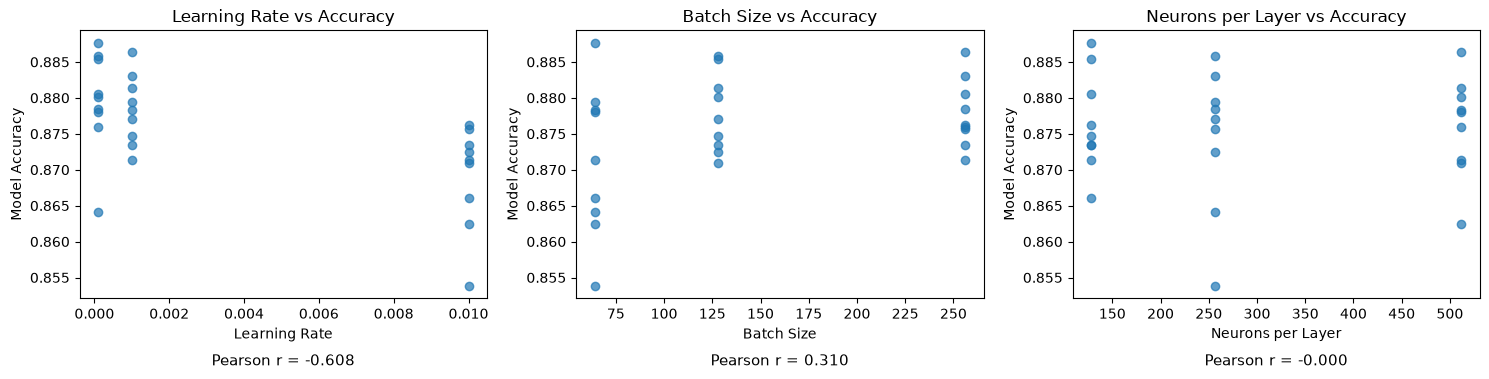

In [42]:
import matplotlib.pyplot as plt

cols   = ["Learning_Rate", "Batch_Size", "Neurons_per_Layer"]
titles = ["Learning Rate", "Batch Size", "Neurons per Layer"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, cols, titles):
    r = df_mlp[col].corr(df_mlp["Model_Accuracy"])
    ax.scatter(df_mlp[col], df_mlp["Model_Accuracy"], alpha=0.7)
    ax.set_xlabel(title)
    ax.set_ylabel("Model Accuracy")
    ax.set_title(f"{title} vs Accuracy")
    ax.text(0.5, -0.25, f"Pearson r = {r:.3f}",
            transform=ax.transAxes, ha="center", fontsize=11)

plt.tight_layout()
plt.show()

**CNN** - The range of the predictions in the CNN is a bit greater with 5.39% (86.67% worst and 92.06% best). An even greater upside can be attributed to grid search for this architecture. Once again the learning rate of 0.01 performed the worst, and no batch size seems to be clearly superior to another. However the most complex filter setup can be found in the top 4 of the list and the best performing combination with least complex filter setup is only the 12th best combination overall.<br>
I also want to point out that there is a significant difference in fitting time between the combinations. The complex filter setups take about 5 times longer to fit compared to the least complex ones. You can also trade off 0.3% performance on the validation set for a gain of only a third of the fitting time.

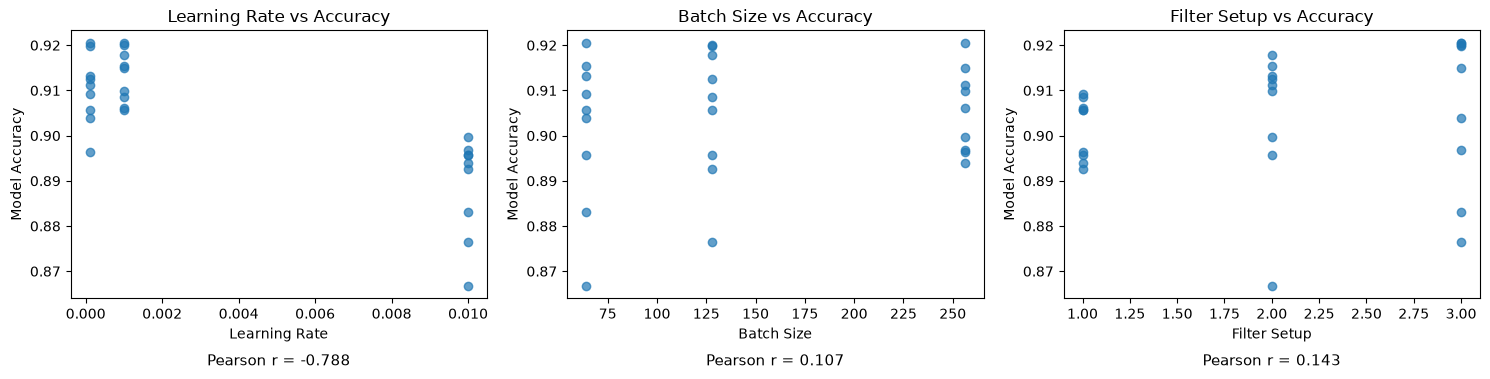

In [43]:
import matplotlib.pyplot as plt

order = {"16;32;64": 1, "32;64;128": 2, "64;128;256": 3}
df_cnn["Filter_ord"] = df_cnn["Filter Setup"].map(order)

cols   = ["Learning_Rate", "Batch_Size", "Filter_ord"]
titles = ["Learning Rate", "Batch Size", "Filter Setup"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, cols, titles):
    r = df_cnn[col].corr(df_cnn["Model_Accuracy"])
    ax.scatter(df_cnn[col], df_cnn["Model_Accuracy"], alpha=0.7)
    ax.set_xlabel(title)
    ax.set_ylabel("Model Accuracy")
    ax.set_title(f"{title} vs Accuracy")
    ax.text(0.5, -0.25, f"Pearson r = {r:.3f}",
            transform=ax.transAxes, ha="center", fontsize=11)

plt.tight_layout()
plt.show()

**5.3 - Error analysis**

On clean data the mistakes concentrated in the visually similar upper-body garments, T-shirt/top, Pullover, Coat, Shirt, with T-shirt/top confused with Shirt being the single biggest confusion (138 for the CNN, 123 for the MLP). Trousers, bags and footwear were easy for both.<br>
The translation didn't just lower accuracy, it changed the error pattern. Predictions drifted heavily toward "Bag" (35.16% of all MLP predictions, 19.13% of the CNN's), and the MLP additionally mislabeled ~70% of trousers as dresses.<br>
The confusion-delta matrix and its Manhattan norm back this up quantitatively. The MLP's total change was more than double the CNN's, i.e. its whole decision structure was far more disturbed by the shift.

**5.4 - Limitations**

I find it hard to point at limitations. Not because I think my approach is perfect, but because I have so little experience, I don't really know what could have been done differently.<br>
I think my grid search is the biggest room for improvement. It could be a lot more extensive and also include different or more hyperparameters that have a greater influence on the performance. I only touched one architecture hyperparameter for each model and I assume they have a great influence.

**AI-Usage in this Project:**<br>
I used AI as support for some code, but I did not blindly paste any code into this notebook without trying to understand what it does. The exception to this are the graphical displays, like pyplots, basically all the cells which are collapsed by default. My personal reasoning for this is being the fact this task is about neural networks and the pyplot's main function is to enhance the understanding of the neural network's behaviour. 